CH = 2.0
CV = 2.0
nx, ny = 10, 10
nv, nc, conec, C, coord = GeraRede(nx, ny , CH, CV)
lst = [0, 1, 2, 30, 31, 32, 93, 103, 113]
C[lst] = 20.0

Cnew:  [20.  20.  20.   2.   2.   2.   2.   2.   2.   2.   2.   2.   2.   2.
  2.   2.   2.   2.   0.2  2.   2.   2.   2.   2.   2.   2.   2.   2.
  2.   2.  20.  20.  20.   0.2  2.   2.   2.   2.   2.   2.   2.   2.
  2.   2.   0.2  2.   2.   2.   2.   2.   0.2  2.   2.   2.   2.   2.
  2.   2.   2.   2.   2.   2.   2.   2.   2.   2.   2.   2.   2.   2.
  0.2  2.   2.   2.   2.   2.   2.   2.   2.   2.   2.   2.   0.2  2.
  2.   2.   2.   0.2  2.   2.   2.   2.   2.  20.   2.   2.   2.   2.
  2.   2.   0.2  2.   2.  20.   2.   2.   2.   2.   2.   2.   2.   2.
  2.  20.   2.   2.   2.   0.2  2.   2.   2.   2.   2.   2.   2.   0.2
  2.   2.   0.2  0.2  2.   2.   2.   2.   2.   2.   2.   2.   2.   2.
  2.   2.   2.   2.   2.   2.   2.   2.   0.2  2.   2.   2.   2.   2.
  2.   0.2  2.   2.   2.   2.   2.   0.2  2.   2.   2.   2.   2.   2.
  0.2  2.   2.   2.   2.   2.   2.   2.   2.   2.   2.   2. ] 

Probabilidade:  0.4925 



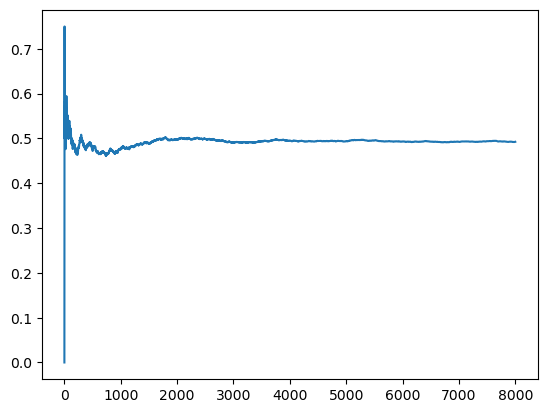

In [11]:
import numpy as np

def GeraRede(nx,ny,CH,CV):
    nv = nx*ny
    nc = (nx-1)*ny + (ny-1)*nx
    
    coord = np.zeros(shape=(nv,2))

    for i in range(nx):
      for j in range(ny):
        ig = i + j*nx
        coord[ig,0] = i
        coord[ig,1] = j

    conec = np.zeros(shape=(nc,2), dtype=int)
    C = np.zeros(nc)
    
    # Loop sobre canos horizontais
    for j in range(ny):
        for i in range(nx-1):
          k = j*(nx-1) + i
          conec[k,0] = j*nx + i
          conec[k,1] = j*nx + i+1
          C[k] = CH

    # Loop sobre canos verticais
    for i in range(nx):
      for j in range(ny-1):
          k = (nx-1)*ny + j*nx + i
          conec[k,0] = i + j*nx
          conec[k,1] = i + (j+1)*nx
          C[k] = CV

    return nv, nc, conec, C, coord

def Assembly(conec, C):
    nv = np.max(conec) + 1 # numero de nós 
    #coloquei +1 pq neste caso, começa em 0
    nc = len(conec[:,0])  # numero de canos
    A = np.zeros(shape=(nv, nv))
    for k in range(nc):
        n1 = conec[k,0]
        n2 = conec[k,1]
        A[n1,n1] = A[n1,n1] + C[k]
        A[n2,n2] = A[n2,n2] + C[k]
        A[n1,n2] = - C[k]
        A[n2,n1] = - C[k]
    return A

def SolveNetwork(conec, natm, nB, QB, C):
    Atilde = Assembly(conec, C)
    Atilde[natm, :] = 0
    Atilde[natm, natm] = 1
    nv = len(Atilde[0,:])
    b = np.zeros(shape=(nv,1))
    b[nB,0] = QB
    pressure = np.linalg.solve(Atilde, b)
    return pressure


#como definir quais canos são grossos ou finos?
def RandomFailFinos(C, p0, Centup):
    Cnew = np.copy(C)
    nc = len(C)
    #print("Quantidade de canos: ", nc, "\n")
    soma = 0
    for k in range(nc):
        if(Cnew[k] == 2.0):
            x = np.random.rand()
            if(x < p0): 
                Cnew[k] = Centup
                soma += 1
        #print("Quantos canos foram entupidos? ", soma, "\n")

    return Cnew

CH = 2.0
CV = 2.0
nx, ny = 10, 10
Centup = 0.2
p0 = 0.1       #depois vai ser variável
nv, nc, conec, C, coord = GeraRede(nx, ny , CH, CV)
lst = [0, 1, 2, 30, 31, 32, 93, 103, 113]
C[lst] = 20.0
nB = 0
natm = nv -1
QB = 10
casos = 0
realizacoes = 8000 #até 10.000

lst_N = []
lst_prob = []
for i in range(realizacoes): 
    Cnew = RandomFailFinos(C, p0, Centup)
    pressao = SolveNetwork(conec, natm, nB, QB, Cnew)
    pmax = np.max(pressao)
    #print(pmax)
    if pmax > 12:
        casos += 1
        
    lst_N.append(i+1)
    lst_prob.append(casos/(i+1))

Prob = casos/realizacoes

print("Cnew: ", Cnew, "\n")
print("Probabilidade: ", Prob, "\n")
import matplotlib.pyplot as plt
plt.plot(lst_N, lst_prob)